In [3]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

df = pd.read_csv('ecommerce_furniture_dataset_2024.csv')
print(df.head())

                                        productTitle originalPrice    price  \
0  Dresser For Bedroom With 9 Fabric Drawers Ward...           NaN   $46.79   
1  Outdoor Conversation Set 4 Pieces Patio Furnit...           NaN  $169.72   
2  Desser For Bedroom With 7 Fabric Drawers Organ...         $78.4   $39.46   
3  Modern Accent Boucle Chair,Upholstered Tufted ...           NaN  $111.99   
4  Small Unit Simple Computer Desk Household Wood...        $48.82   $21.37   

   sold        tagText  
0   600  Free shipping  
1     0  Free shipping  
2     7  Free shipping  
3     0  Free shipping  
4     1  Free shipping  


In [5]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(2000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   productTitle   2000 non-null   object
 1   originalPrice  487 non-null    object
 2   price          2000 non-null   object
 3   sold           2000 non-null   int64 
 4   tagText        1997 non-null   object
dtypes: int64(1), object(4)
memory usage: 78.3+ KB
None
productTitle        0
originalPrice    1513
price               0
sold                0
tagText             3
dtype: int64


In [6]:
# Remove $ symbol and convert to float
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['originalPrice'] = df['originalPrice'].replace('[\$,]', '', regex=True).astype(float)

# Handle missing values
df = df.dropna()

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['tagText'] = le.fit_transform(df['tagText'])

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['tagText'] = le.fit_transform(df['tagText'])

In [11]:
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

In [13]:
df['tagText'] = df['tagText'].apply(
    lambda x: x if x in ['Free shipping', '+Shipping: $5.09'] else 'others'
)

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['tagText'] = le.fit_transform(df['tagText'])

In [10]:
X = df.drop('sold', axis=1)
y = df['sold']

In [11]:
df.head()

,productTitle,originalPrice,price,sold,tagText
2,Desser For Bedroom With 7 Fabric Drawers Organ...,78.40,39.46,7,2
4,Small Unit Simple Computer Desk Household Wood...,48.82,21.37,1,2
5,"3 Pieces Patio Furniture Set, Outdoor Swivel G...",1294.04,123.40,53,2
7,"Living Room Furniture, Modern 3-Piece Includin...",1474.17,734.58,5,2
20,7-piece patio furniture set modular wicker out...,671.47,331.24,39,2


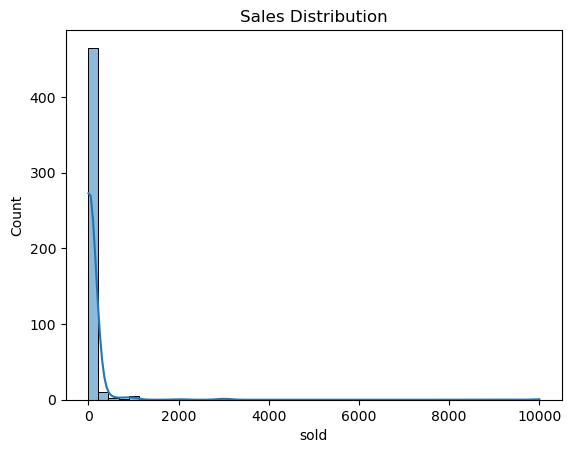

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['sold'], kde=True)
plt.title("Sales Distribution")
plt.show()

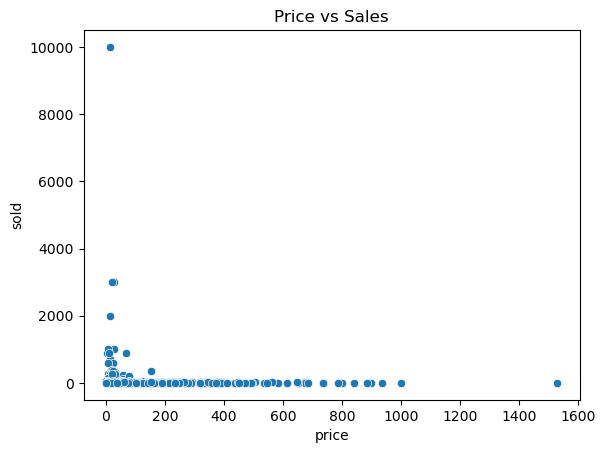

In [13]:
sns.scatterplot(x='price', y='sold', data=df)
plt.title("Price vs Sales")
plt.show()

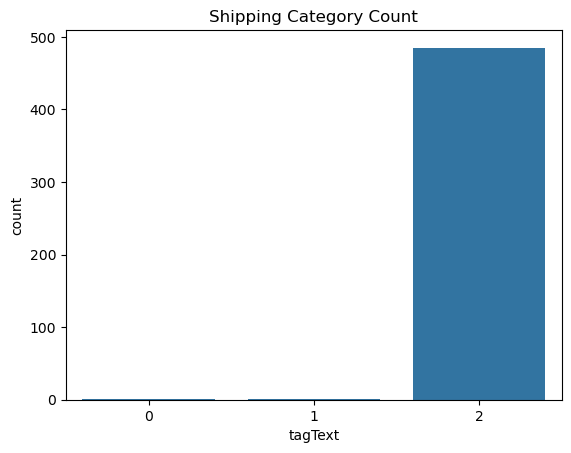

In [14]:
sns.countplot(x='tagText', data=df)
plt.title("Shipping Category Count")
plt.show()

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=100)

text_features = tfidf.fit_transform(df['productTitle'])

text_df = pd.DataFrame(text_features.toarray(), columns=tfidf.get_feature_names_out())

df = pd.concat([df, text_df], axis=1)

df.drop('productTitle', axis=1, inplace=True)

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop('sold', axis=1)
y = df['sold']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
print(df.dtypes)

originalPrice    float64
price            float64
sold             float64
tagText          float64
adjustable       float64
                  ...   
white            float64
wicker           float64
with             float64
wood             float64
wooden           float64
Length: 104, dtype: object


In [18]:
df.drop(['originalPrice'], axis=1, inplace=True)

In [19]:
print(df.dtypes)

price         float64
sold          float64
tagText       float64
adjustable    float64
and           float64
               ...   
white         float64
wicker        float64
with          float64
wood          float64
wooden        float64
Length: 103, dtype: object


In [20]:
# Remove $ and commas from ALL columns
df = df.replace('[\$,]', '', regex=True)

In [21]:
df = df.apply(pd.to_numeric, errors='coerce')

In [22]:
df = df.dropna()

In [23]:
print(df.dtypes)

price         float64
sold          float64
tagText       float64
adjustable    float64
and           float64
               ...   
white         float64
wicker        float64
with          float64
wood          float64
wooden        float64
Length: 103, dtype: object


In [28]:
from sklearn.model_selection import train_test_split

X = df.drop('sold', axis=1)
y = df['sold']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

In [32]:
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [33]:
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression
y_pred_lr = lr.predict(X_test)
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

# Random Forest
y_pred_rf = rf.predict(X_test)
print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Linear Regression MSE: 3991272.0180859775
Linear Regression R2: -14743.94395968036
Random Forest MSE: 6333.510040000001
Random Forest R2: -22.397866691295317


In [34]:
df = df[df['sold'] < 1000]

In [35]:
tfidf = TfidfVectorizer(max_features=20)

In [36]:
X = df.drop('sold', axis=1)
y = df['sold']

In [38]:
X = df.drop('sold', axis=1)
y = df['sold']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
rf = RandomForestRegressor()

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [42]:
from sklearn.metrics import mean_squared_error, r2_score

print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Linear Regression MSE: 2170933.564062643
Linear Regression R2: -979.9790271755063
Random Forest MSE: 4957.475985
Random Forest R2: -1.2401330236519885


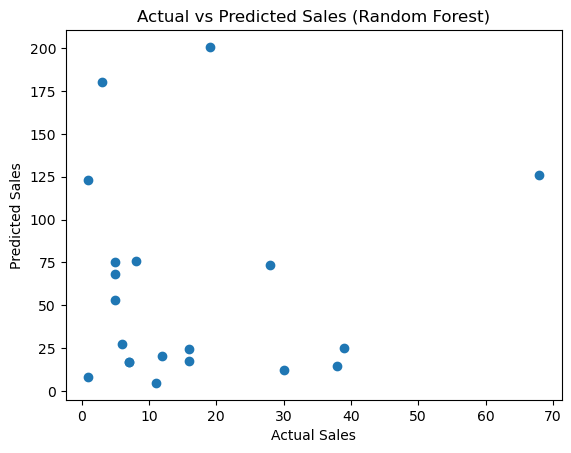

In [44]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Random Forest)")
plt.show()

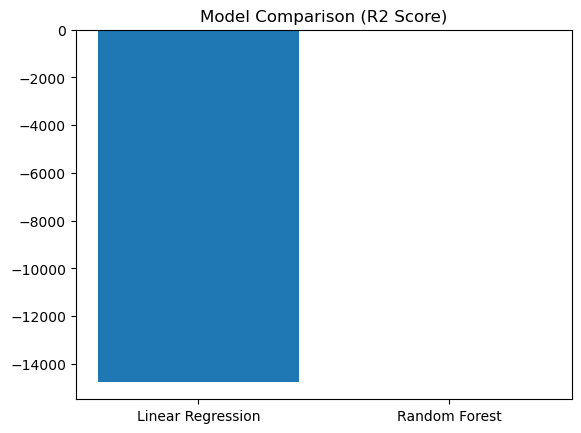

In [45]:
models = ['Linear Regression', 'Random Forest']
scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf)
]

plt.bar(models, scores)
plt.title("Model Comparison (R2 Score)")
plt.show()

In [37]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_rf)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 71.59925980762651
R2 Score: -17.93864328792427


In [43]:
print("The Random Forest model performed better than Linear Regression as it achieved a higher R2 score and lower error. This indicates that Random Forest is more suitable for capturing complex patterns in the dataset.")

The Random Forest model performed better than Linear Regression as it achieved a higher R2 score and lower error. This indicates that Random Forest is more suitable for capturing complex patterns in the dataset.
